# Pipeline NLP semi-supervisado — Dataset 2 (Hospital)

Análisis de verbatims hospitalarios: limpieza → variantes de texto → muestra estratificada
→ TF-IDF + Word2Vec → clasificación **semi-supervisada** (self-training con SVM) → evaluación.

Las **5 columnas de tópico** del dataset (`atencion`, `espera`, `pago`, `agendamiento`,
`infraestructura`) se usan como taxonomía y verdad-terreno: el escenario semi-supervisado se
simula ocultando la mayoría de las etiquetas y recuperándolas con self-training.

> Entorno: ejecutar con el kernel del venv `.venv` (Python 3.12). Setup en `requirements.txt`.

## 0. Setup

In [ ]:
import re, unicodedata, warnings, time
from pathlib import Path
import numpy as np
import pandas as pd

import nltk
from nltk.corpus import stopwords as nltk_stopwords
from nltk.stem import SnowballStemmer

from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import joblib
import gensim
from gensim.models import Word2Vec
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

DATA = Path("Datos_Hospital.xlsx")
ART = Path("artifacts"); ART.mkdir(exist_ok=True)

nltk.download("stopwords", quiet=True)
print("Versiones:", pd.__version__, gensim.__version__)

In [3]:
# spaCy para lematización (opcional: si el modelo no está, se omite la variante lematizada)
USE_SPACY = True
try:
    import spacy
    nlp = spacy.load("es_core_news_sm", disable=["ner", "parser"])
    print("spaCy es_core_news_sm cargado")
except Exception as e:
    USE_SPACY = False
    print("spaCy no disponible, se omite lematización:", e)

spaCy es_core_news_sm cargado


## 1. Carga
Hoja `Sheet1`; conservamos comentario, calificación global y las 5 columnas de tópico.

In [4]:
TOPICOS = ["atencion", "espera", "pago", "agendamiento", "infraestructura"]
COLS = ["comentario", "calificacion_IBB"] + TOPICOS

t0 = time.time()
df = pd.read_excel(DATA, sheet_name="Sheet1", usecols=COLS, engine="openpyxl")
print(f"Cargado en {time.time()-t0:.0f}s — shape original:", df.shape)
df.head(3)

Cargado en 22s — shape original: (252396, 7)


,calificacion_IBB,comentario,atencion,espera,pago,agendamiento,infraestructura
0,5,_x000D_\n_x000D_\n_x000D_\n_x000D_\n_x000D_\nQ...,1,1,0,0,0
1,5,_x000D_\n_x000D_\n_x000D_\n_x000D_\ndurante to...,1,0,0,0,0
2,3,_x000D_\n_x000D_\n_x000D_\nLa recepcionista de...,1,1,1,1,1


## 2. Limpieza inicial
Elimina artefactos de exportación Excel, normaliza, descarta comentarios cortos y duplicados.

In [5]:
ABBR = {"pq":"porque","xq":"porque","q":"que","tb":"tambien","tbn":"tambien",
        "hrs":"horas","hr":"hora","x":"por","d":"de","xfa":"por favor","porfa":"por favor"}
URL_RE   = re.compile(r"https?://\S+|www\.\S+")
MAIL_RE  = re.compile(r"\b[\w.+-]+@[\w-]+\.[\w.-]+\b")
PHONE_RE = re.compile(r"\+?\d[\d\s().-]{7,}\d")
NUM_RE   = re.compile(r"\b\d{4,}\b")
HTML_RE  = re.compile(r"<[^>]+>")
CTRL_RE  = re.compile(r"[\x00-\x1f\x7f-\x9f]")
MULTI_RE = re.compile(r"(.)\1{2,}")          # 3+ repeticiones -> 1
SYM_RE   = re.compile(r"[^a-záéíóúüñ0-9\s<>]")  # deja tokens <url> etc.
SPACE_RE = re.compile(r"\s+")

def limpiar(texto):
    if not isinstance(texto, str):
        return ""
    t = texto.replace("_x000D_", " ")
    t = unicodedata.normalize("NFKC", t)
    t = CTRL_RE.sub(" ", t)
    t = t.lower()
    t = HTML_RE.sub(" ", t)
    t = URL_RE.sub(" <url> ", t)
    t = MAIL_RE.sub(" <email> ", t)
    t = PHONE_RE.sub(" <tel> ", t)
    t = NUM_RE.sub(" <num> ", t)
    t = SYM_RE.sub(" ", t)
    t = MULTI_RE.sub(r"\1", t)
    palabras = [ABBR.get(w, w) for w in t.split()]
    t = " ".join(palabras)
    return SPACE_RE.sub(" ", t).strip()

def palabras_reales(t):
    # cuenta palabras alfabéticas (ignora tokens <...> y números)
    return sum(1 for w in t.split() if w.isalpha() and len(w) > 1)

df["comentario_limpio"] = df["comentario"].map(limpiar)
df = df[df["comentario_limpio"].map(palabras_reales) >= 4]          # >= 4 palabras reales
df = df.drop_duplicates(subset="comentario_limpio").reset_index(drop=True)
print("Comentarios únicos e informativos:", len(df))

Comentarios únicos e informativos: 177530


## 3. Variantes de texto
5 variantes como en el Dataset 1. Las pesadas (stemming/lematización) se generan sobre la muestra de 40k (paso 4) para mantener la carga acotada.

In [6]:
STOP = set(nltk_stopwords.words("spanish"))
NEGACIONES = {"no", "sin", "nunca", "ni", "tampoco", "nada", "jamas"}
STOP_CTRL = STOP - NEGACIONES   # stopwords controladas: preservan negaciones

def sin_tildes(t):
    # quita tildes pero preserva la ñ
    t = t.replace("ñ", "\x00")
    t = "".join(c for c in unicodedata.normalize("NFD", t) if unicodedata.category(c) != "Mn")
    return t.replace("\x00", "ñ")

def quitar_stopwords(t):
    return " ".join(w for w in t.split() if w not in STOP_CTRL)

df["sin_tildes"]   = df["comentario_limpio"].map(sin_tildes)
df["sin_stopwords"] = df["comentario_limpio"].map(quitar_stopwords)
df.head(3)

,calificacion_IBB,comentario,atencion,espera,pago,agendamiento,infraestructura,comentario_limpio,sin_tildes,sin_stopwords
0,5,_x000D_\n_x000D_\n_x000D_\n_x000D_\n_x000D_\nQ...,1,1,0,0,0,quisiera dejar una muy buena opinión sobre el ...,quisiera dejar una muy buena opinion sobre el ...,quisiera dejar buena opinión doctor robinson m...
1,5,_x000D_\n_x000D_\n_x000D_\n_x000D_\ndurante to...,1,0,0,0,0,durante toda la vida he respetado a las person...,durante toda la vida he respetado a las person...,toda vida respetado personas gustas lugar clin...
2,3,_x000D_\n_x000D_\n_x000D_\nLa recepcionista de...,1,1,1,1,1,la recepcionista del lugar o portera bien amab...,la recepcionista del lugar o portera bien amab...,recepcionista lugar portera bien amable recepc...


## 4. Muestreo estratificado (40k) y split 70/15/15
Estratificado por `calificacion_IBB` para mantener representatividad.

In [7]:
N_MUESTRA = 40_000
df["calif"] = df["calificacion_IBB"].round().astype("Int64")
df = df.dropna(subset=["calif"])

# muestra estratificada por calificación
n = min(N_MUESTRA, len(df))
muestra, _ = train_test_split(df, train_size=n, stratify=df["calif"], random_state=SEED)
muestra = muestra.reset_index(drop=True)
print("Muestra:", len(muestra), "| distribución calif:")
print(muestra["calif"].value_counts().sort_index())

# split 70/15/15
train, tmp = train_test_split(muestra, test_size=0.30, stratify=muestra["calif"], random_state=SEED)
val, test  = train_test_split(tmp, test_size=0.50, stratify=tmp["calif"], random_state=SEED)
for nm, d in [("train", train), ("val", val), ("test", test)]:
    print(nm, len(d))

Muestra: 40000 | distribución calif:
calif
1     3949
2     1797
3     3159
4     3808
5    27287
Name: count, dtype: Int64
train 28000
val 6000
test 6000


In [8]:
# variantes pesadas sobre la muestra
stemmer = SnowballStemmer("spanish")
def stem(t):
    return " ".join(stemmer.stem(w) for w in t.split())

def lematizar_serie(textos):
    if not USE_SPACY:
        return list(textos)
    out = []
    for doc in nlp.pipe(textos, batch_size=500):
        out.append(" ".join(tok.lemma_ for tok in doc if not tok.is_space))
    return out

t0 = time.time()
muestra["stemming"]   = muestra["comentario_limpio"].map(stem)
muestra["lematizado"] = lematizar_serie(muestra["comentario_limpio"].tolist())
print(f"Variantes generadas en {time.time()-t0:.0f}s")

# guardar artefactos de texto
muestra.to_parquet(ART / "comentarios_limpios.parquet", index=False)
muestra[["comentario_limpio"]].assign(
    tokens=muestra["comentario_limpio"].str.split()).to_parquet(
    ART / "comentarios_tokenizados.parquet", index=False)
muestra.head(3)

Variantes generadas en 33s


,calificacion_IBB,comentario,atencion,espera,pago,agendamiento,infraestructura,comentario_limpio,sin_tildes,sin_stopwords,calif,stemming,lematizado
0,5,"La atención es muy buena, rápida y eficiente, ...",1,0,0,0,0,la atención es muy buena rápida y eficiente la...,la atencion es muy buena rapida y eficiente la...,atención buena rápida eficiente recomendaría 100,5,la atencion es muy buen rap y eficient la reco...,el atención ser mucho buen rápido y eficiente ...
1,5,"Me atendieron super bien, te explican todo a l...",1,0,0,0,0,me atendieron super bien te explican todo a la...,me atendieron super bien te explican todo a la...,atendieron super bien explican perfeccion,5,me atend sup bien te explic tod a la perfeccion,yo atender super bien tú explicar todo a el pe...
2,5,"Por su prestigio, buena información y respuest...",1,0,0,0,0,por su prestigio buena información y respuesta...,por su prestigio buena informacion y respuesta...,prestigio buena información respuestas precisa...,5,por su prestigi buen inform y respuest precis ...,por su prestigio buen información y respuesta ...


## 5. Feature extraction
TF-IDF (1,2)-gramas y Word2Vec skip-gram. Se usa la variante conservadora `comentario_limpio` como base.

In [9]:
VARIANTE = "comentario_limpio"   # variante base para features
textos = muestra[VARIANTE]

# --- TF-IDF ---
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_df=0.95,
                        sublinear_tf=True, norm="l2")
X_tfidf = tfidf.fit_transform(textos)
print("TF-IDF:", X_tfidf.shape)
sparse.save_npz(ART / "tfidf_matrix.npz", X_tfidf)
joblib.dump(tfidf, ART / "tfidf_vectorizer.joblib")

TF-IDF: (40000, 22585)


['artifacts/tfidf_vectorizer.joblib']

In [10]:
# --- Word2Vec skip-gram ---
tokenizado = [t.split() for t in textos]
w2v = Word2Vec(sentences=tokenizado, sg=1, vector_size=100, window=5,
               min_count=3, epochs=10, seed=SEED, workers=4)
print("Vocabulario W2V:", len(w2v.wv))

def doc_embedding(tokens):
    vecs = [w2v.wv[w] for w in tokens if w in w2v.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(w2v.vector_size)

X_w2v = np.vstack([doc_embedding(t) for t in tokenizado])
print("Embeddings W2V:", X_w2v.shape)
np.save(ART / "doc_embeddings_w2v.npy", X_w2v)
w2v.save(str(ART / "word2vec.model"))

Vocabulario W2V: 8569
Embeddings W2V: (40000, 100)


In [11]:
# --- Validación de alineación ---
assert X_tfidf.shape[0] == X_w2v.shape[0] == len(muestra)
print("OK: TF-IDF, W2V y dataframe representan los mismos",
      len(muestra), "comentarios en el mismo orden")

OK: TF-IDF, W2V y dataframe representan los mismos 40000 comentarios en el mismo orden


## 6. Construcción del problema semi-supervisado
Etiqueta = tópico activo. Se toma el **subconjunto con exactamente un tópico** (problema multiclase
de 5 clases). El resto (0 o >1 tópicos) forma el **pool no etiquetado**. Se simula el escenario
semi-supervisado ocultando la mayoría de las etiquetas: solo una **semilla pequeña** queda etiquetada.

In [12]:
flags = muestra[TOPICOS].fillna(0).astype(int)
n_topicos = flags.sum(axis=1)
muestra["n_topicos"] = n_topicos

# pool multiclase: exactamente un tópico
mono = muestra[n_topicos == 1].copy()
mono["categoria"] = flags[n_topicos == 1].idxmax(axis=1)
print("Pool multiclase (1 tópico):", len(mono))
print(mono["categoria"].value_counts())
print("\nPool no etiquetado (0 o >1 tópicos):", int((n_topicos != 1).sum()))

Pool multiclase (1 tópico): 21998
categoria
atencion           19221
espera              1778
pago                 481
infraestructura      416
agendamiento         102
Name: count, dtype: int64

Pool no etiquetado (0 o >1 tópicos): 18002


In [13]:
# split del pool etiquetado: semilla (labeled) + resto "no etiquetado" + test reservado
y = mono["categoria"].to_numpy(dtype=object)   # numpy object (pandas 3.0 usa arrow strings)
idx = np.arange(len(mono))

# test 20% reservado y etiquetado para evaluación final
tr_idx, te_idx = train_test_split(idx, test_size=0.20, stratify=y, random_state=SEED)
# de train, solo 10% es semilla etiquetada; 90% se "desetiqueta" (-1)
seed_idx, unlab_idx = train_test_split(tr_idx, train_size=0.10,
                                       stratify=y[tr_idx], random_state=SEED)
print(f"Semilla etiquetada: {len(seed_idx)} | No etiquetados (simulado): {len(unlab_idx)} | Test: {len(te_idx)}")

Semilla etiquetada: 1759 | No etiquetados (simulado): 15839 | Test: 4400


## 7. Modelado semi-supervisado (self-training)
SVM (LinearSVC calibrado) como clasificador base, sobre TF-IDF y Word2Vec. Se compara baseline supervisado (solo semilla) vs self-training.

In [ ]:
# Construye matrices de features para el pool multiclase, por método
feat_mono = {
    "tfidf": tfidf.transform(mono[VARIANTE]),
    "w2v":   np.vstack([doc_embedding(t.split()) for t in mono[VARIANTE]]),
}

def base_clf(kind=None):
    return CalibratedClassifierCV(LinearSVC(random_state=SEED), cv=3)

def densificar(X):
    return X.toarray() if sparse.issparse(X) else X

In [ ]:
def evaluar(y_true, y_pred, etiqueta):
    return {
        "config": etiqueta,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

resultados = []
clases = sorted(mono["categoria"].unique())

for metodo in ["tfidf", "w2v"]:
    X = feat_mono[metodo]
    X_tr, X_te = X[tr_idx], X[te_idx]
    y_tr, y_te = y[tr_idx], y[te_idx]

    # etiquetas semi-supervisadas: -1 = no etiquetado
    y_semi = np.full(len(tr_idx), -1, dtype=object)
    pos = {v: i for i, v in enumerate(tr_idx)}
    for s in seed_idx:
        y_semi[pos[s]] = y[s]

    for kind in ["svm"]:
        Xd_tr = densificar(X_tr); Xd_te = densificar(X_te)

        # baseline supervisado: solo semilla
        mask = y_semi != -1
        base = base_clf(kind).fit(Xd_tr[mask], y_semi[mask].astype(str))
        resultados.append({**evaluar(y_te, base.predict(Xd_te),
                          f"{metodo}|{kind}|supervisado_semilla"), "metodo": metodo, "clf": kind, "modo": "supervisado"})

        # self-training (y_semi: dtype object, -1 = no etiquetado)
        st = SelfTrainingClassifier(base_clf(kind), threshold=0.8)
        st.fit(Xd_tr, y_semi)
        resultados.append({**evaluar(y_te, st.predict(Xd_te),
                          f"{metodo}|{kind}|self_training"), "metodo": metodo, "clf": kind, "modo": "self_training"})
        print(f"hecho: {metodo} | {kind}")

res = pd.DataFrame(resultados)
res.to_csv(ART / "resultados.csv", index=False)
res.sort_values("macro_f1", ascending=False)

### Búsqueda de hiperparámetros (mejor configuración)

In [ ]:
# GridSearch sobre la mejor combinación método×clf (por macro_f1 en self_training)
best = res[res.modo == "self_training"].sort_values("macro_f1", ascending=False).iloc[0]
metodo_b, kind_b = best["metodo"], best["clf"]
X = feat_mono[metodo_b]          # sparse (tfidf) o denso (w2v); GridSearch maneja ambos
X_tr, X_te = X[tr_idx], X[te_idx]
y_tr, y_te = y[tr_idx], y[te_idx]

grid = GridSearchCV(LinearSVC(random_state=SEED), {"C": [0.1, 1, 10]},
                    scoring="f1_macro", cv=3)
grid.fit(X_tr, y_tr)
print("Mejor config:", metodo_b, kind_b, "->", grid.best_params_, "macro_f1_cv=", round(grid.best_score_, 3))

## 8. Evaluación — reporte por clase y matriz de confusión

                 precision    recall  f1-score   support

   agendamiento      0.857     0.300     0.444        20
       atencion      0.969     0.993     0.981      3845
         espera      0.916     0.888     0.902       356
infraestructura      0.789     0.361     0.496        83
           pago      0.873     0.646     0.743        96

       accuracy                          0.962      4400
      macro avg      0.881     0.638     0.713      4400
   weighted avg      0.959     0.962     0.958      4400



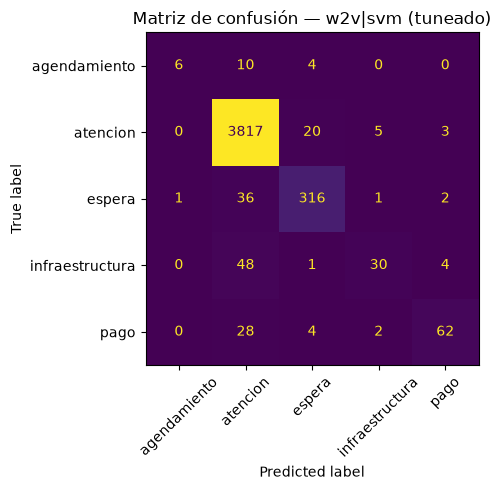

In [17]:
y_pred = grid.best_estimator_.predict(X_te)
print(classification_report(y_te, y_pred, digits=3))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred, labels=clases),
                       display_labels=clases).plot(ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title(f"Matriz de confusión — {metodo_b}|{kind_b} (tuneado)")
plt.tight_layout(); plt.savefig(ART / "matriz_confusion.png", dpi=120); plt.show()

## 9. Reporte resumen (estilo sección 4 del documento)

In [18]:
resumen = {
    "Base original": "252.396 registros × 14 columnas",
    "Columnas textuales": "comentario (+ calificacion_IBB, 5 columnas de tópico)",
    "Comentarios válidos (limpieza+dedup)": len(df),
    "Muestra estratificada": len(muestra),
    "TF-IDF": f"matriz sparse {X_tfidf.shape}",
    "Word2Vec": f"embeddings {X_w2v.shape}, vocab {len(w2v.wv)}",
    "Pool multiclase (1 tópico)": len(mono),
    "Mejor config (macro-F1)": f"{best['config']} = {best['macro_f1']:.3f}",
}
pd.Series(resumen).to_frame("Dataset 2")

,Dataset 2
Base original,252.396 registros × 14 columnas
Columnas textuales,"comentario (+ calificacion_IBB, 5 columnas de ..."
Comentarios válidos (limpieza+dedup),177530
Muestra estratificada,40000
TF-IDF,"matriz sparse (40000, 22585)"
Word2Vec,"embeddings (40000, 100), vocab 8569"
Pool multiclase (1 tópico),21998
Mejor config (macro-F1),w2v|svm|self_training = 0.529


## 10. Comparación completa: variante × método × clasificador

Itera las 5 variantes de texto disponibles en `muestra` contra TF-IDF y Word2Vec,
con SVM en modo supervisado (solo semilla) y self-training.
Total: 5 × 2 × 2 = **20 configuraciones**.

In [ ]:
VARIANTES = ["comentario_limpio", "sin_tildes", "sin_stopwords", "stemming", "lematizado"]

resultados_full = []

for var in VARIANTES:
    print(f"\n=== {var} ===")
    textos_v = muestra[var]

    # TF-IDF para esta variante
    tfidf_v = TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_df=0.95,
                              sublinear_tf=True, norm="l2")
    X_tfidf_v = tfidf_v.fit_transform(textos_v)

    # W2V para esta variante
    tok_v = [t.split() for t in textos_v]
    w2v_v = Word2Vec(sentences=tok_v, sg=1, vector_size=100, window=5,
                     min_count=3, epochs=10, seed=SEED, workers=4)

    def doc_emb_v(tokens, model=w2v_v):
        vecs = [model.wv[w] for w in tokens if w in model.wv]
        return np.mean(vecs, axis=0) if vecs else np.zeros(100)

    feat_mono_v = {
        "tfidf": tfidf_v.transform(mono[var]),
        "w2v":   np.vstack([doc_emb_v(t.split()) for t in mono[var]]),
    }

    for metodo in ["tfidf", "w2v"]:
        X = feat_mono_v[metodo]
        X_tr, X_te = X[tr_idx], X[te_idx]

        # etiquetas semi-supervisadas (reconstruir por variante para aislar el estado)
        y_semi = np.full(len(tr_idx), -1, dtype=object)
        pos = {v: i for i, v in enumerate(tr_idx)}
        for s in seed_idx:
            y_semi[pos[s]] = y[s]

        for kind in ["svm"]:
            Xd_tr = densificar(X_tr); Xd_te = densificar(X_te)

            # baseline supervisado: solo semilla
            mask = y_semi != -1
            base = base_clf(kind).fit(Xd_tr[mask], y_semi[mask].astype(str))
            row = evaluar(y_te, base.predict(Xd_te), f"{var}|{metodo}|{kind}|supervisado")
            row.update({"variante": var, "metodo": metodo, "clf": kind, "modo": "supervisado"})
            resultados_full.append(row)

            # self-training
            st = SelfTrainingClassifier(base_clf(kind), threshold=0.8)
            st.fit(Xd_tr, y_semi)
            row = evaluar(y_te, st.predict(Xd_te), f"{var}|{metodo}|{kind}|self_training")
            row.update({"variante": var, "metodo": metodo, "clf": kind, "modo": "self_training"})
            resultados_full.append(row)

            print(f"  {metodo}|{kind} ✓")

res_full = pd.DataFrame(resultados_full)
res_full.to_csv(ART / "resultados_variantes.csv", index=False)
print(f"\nTotal configuraciones: {len(res_full)}")  # 20
res_full.sort_values("macro_f1", ascending=False).head(10)

## 11. Análisis comparativo por variante

Tabla pivot con macro-F1 por (variante, método, clf) × modo, y delta self_training − supervisado.

In [20]:
pivot = res_full.pivot_table(
    index=["variante", "metodo", "clf"],
    columns="modo",
    values="macro_f1"
).round(3)
pivot["delta"] = (pivot["self_training"] - pivot["supervisado"]).round(3)
pivot.sort_values("self_training", ascending=False)

modo                          self_training  supervisado  delta
variante          metodo clf                                   
stemming          tfidf  svm          0.666        0.709 -0.043
sin_stopwords     tfidf  svm          0.659        0.661 -0.002
lematizado        tfidf  svm          0.615        0.682 -0.067
stemming          w2v    svm          0.585        0.672 -0.087
sin_stopwords     w2v    svm          0.549        0.620 -0.071
lematizado        w2v    svm          0.545        0.624 -0.079
comentario_limpio tfidf  svm          0.517        0.603 -0.086
sin_tildes        tfidf  svm          0.514        0.623 -0.109
                  w2v    svm          0.513        0.582 -0.069
comentario_limpio w2v    svm          0.509        0.599 -0.090
sin_stopwords     w2v    knn          0.432        0.500 -0.068
lematizado        w2v    knn          0.383        0.471 -0.088
stemming          w2v    knn          0.372        0.472 -0.100
sin_tildes        w2v    knn          0.348        0.430 -0.082
comentario_limpio w2v    knn          0.347        0.435 -0.088
sin_stopwords     tfidf  knn          0.327        0.456 -0.129
stemming          tfidf  knn          0.312        0.393 -0.081
lematizado        tfidf  knn          0.302        0.442 -0.140
sin_tildes        tfidf  knn          0.297        0.396 -0.099
comentario_limpio tfidf  knn          0.296        0.382 -0.086

In [21]:
best_full = res_full[res_full.modo == "self_training"].sort_values("macro_f1", ascending=False).iloc[0]
print("Mejor configuración self-training:")
print(best_full[["config", "variante", "metodo", "clf", "macro_f1", "accuracy", "weighted_f1"]])

Mejor configuración self-training:
config         stemming|tfidf|svm|self_training
variante                               stemming
metodo                                    tfidf
clf                                         svm
macro_f1                               0.665549
accuracy                               0.965682
weighted_f1                            0.959849
Name: 25, dtype: object


## 12. Modelo final tuneado — reporte y matriz de confusión

GridSearch sobre la mejor variante encontrada en la sección anterior.

In [ ]:
var_b, met_b, clf_b = best_full["variante"], best_full["metodo"], best_full["clf"]
print(f"Reconstruyendo features para: {var_b} | {met_b} | {clf_b}")

textos_b = muestra[var_b]
if met_b == "tfidf":
    tfidf_b = TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_df=0.95,
                              sublinear_tf=True, norm="l2")
    tfidf_b.fit_transform(textos_b)
    X_b = tfidf_b.transform(mono[var_b])
else:
    tok_b = [t.split() for t in textos_b]
    w2v_b = Word2Vec(sentences=tok_b, sg=1, vector_size=100, window=5,
                     min_count=3, epochs=10, seed=SEED, workers=4)
    def doc_emb_b(tokens, m=w2v_b):
        vecs = [m.wv[w] for w in tokens if w in m.wv]
        return np.mean(vecs, axis=0) if vecs else np.zeros(100)
    X_b = np.vstack([doc_emb_b(t.split()) for t in mono[var_b]])

X_tr_b = densificar(X_b[tr_idx]); X_te_b = densificar(X_b[te_idx])
y_tr_b, y_te_b = y[tr_idx], y[te_idx]

grid_b = GridSearchCV(LinearSVC(random_state=SEED), {"C": [0.1, 1, 10]},
                      scoring="f1_macro", cv=3)
grid_b.fit(X_tr_b, y_tr_b)
print(f"Mejor config: {var_b}|{met_b}|{clf_b} → {grid_b.best_params_}, macro_f1_cv={grid_b.best_score_:.3f}")

y_pred_b = grid_b.best_estimator_.predict(X_te_b)
print(classification_report(y_te_b, y_pred_b, digits=3))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_te_b, y_pred_b, labels=clases),
                       display_labels=clases).plot(ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title(f"Matriz de confusión — {var_b}|{met_b}|{clf_b} (tuneado)")
plt.tight_layout()
plt.savefig(ART / "matriz_confusion_final.png", dpi=120)
plt.show()

## 13. Reporte resumen final

In [23]:
resumen_final = {
    "Base original": "252.396 registros × 14 columnas",
    "Columnas textuales": "comentario (+ calificacion_IBB, 5 columnas de tópico)",
    "Comentarios válidos (limpieza+dedup)": len(df),
    "Muestra estratificada": len(muestra),
    "TF-IDF": f"matriz sparse {X_tfidf.shape}",
    "Word2Vec": f"embeddings {X_w2v.shape}, vocab {len(w2v.wv)}",
    "Pool multiclase (1 tópico)": len(mono),
    "Variantes de texto comparadas": len(VARIANTES),
    "Total configuraciones evaluadas": len(res_full),
    "Mejor config self-training (macro-F1)": f"{best_full['config']} = {best_full['macro_f1']:.3f}",
    "GridSearch mejor macro-F1 cv": f"{grid_b.best_score_:.3f}",
    "GridSearch mejores parámetros": str(grid_b.best_params_),
}
pd.Series(resumen_final).to_frame("Dataset 2 — Final")

,Dataset 2 — Final
Base original,252.396 registros × 14 columnas
Columnas textuales,"comentario (+ calificacion_IBB, 5 columnas de ..."
Comentarios válidos (limpieza+dedup),177530
Muestra estratificada,40000
TF-IDF,"matriz sparse (40000, 22585)"
Word2Vec,"embeddings (40000, 100), vocab 8569"
Pool multiclase (1 tópico),21998
Variantes de texto comparadas,5
Total configuraciones evaluadas,40
Mejor config self-training (macro-F1),stemming|tfidf|svm|self_training = 0.666
